In [262]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import matplotlib.image as mpimg
from scipy.interpolate import CubicSpline

Start Coordinate: [526 200]
End Coordinate: [111 173]


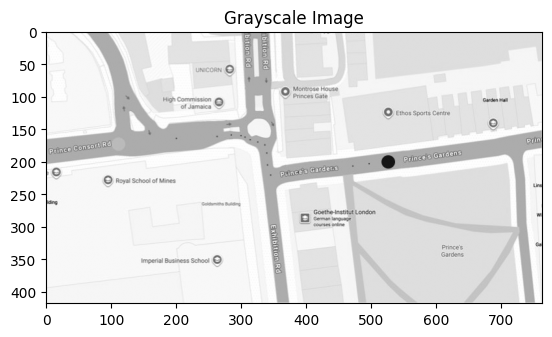

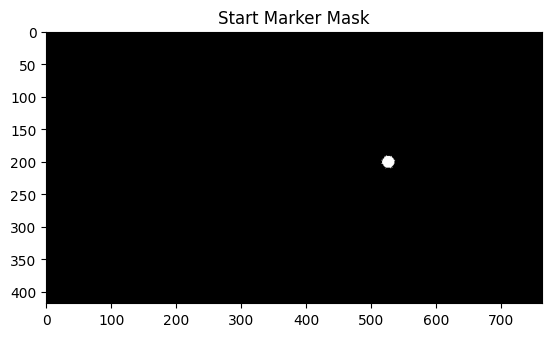

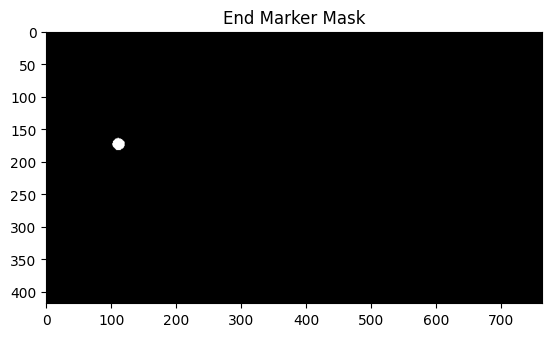

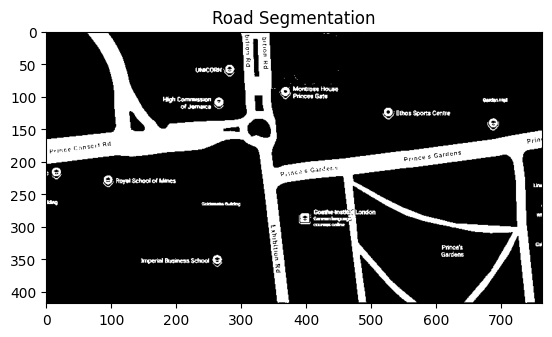

In [263]:

img = mpimg.imread('CW2Map.jpg') 

# Normalize to 0-1 range
img = img.astype(float) / 255.0

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]


red_mask = (R > 0.7) & (G < 0.4) & (B < 0.4)

green_mask = (G > 0.6) & (G > R * 1.5) & (G > B * 1.5)

def find_point(mask):
    coords = np.argwhere(mask)
    if len(coords) == 0: return None
    return np.mean(coords, axis=0)[::-1].astype(int) 

start_pos = find_point(red_mask)
end_pos = find_point(green_mask)

print(f"Start Coordinate: {start_pos}")
print(f"End Coordinate: {end_pos}")


# Convert to grayscale to isolate the grey paths 
gray = 0.299 * R + 0.587 * G + 0.114 * B

road_mask = (gray < 0.85) & (gray > 0.1) 

# show greyscale image
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.show()


def convolution(image, kernel, w):
    """
    w is the width of the kernel
    """
    img_h, img_w = image.shape
    
    # Create an empty output array of the same size
    output = np.zeros((img_h, img_w))
    
    # ignore the 1-pixel border to avoid going out of bounds
    for y in range(1, img_h - 1):
        for x in range(1, img_w - 1):
            region = image[y-(w//2):y+(w//2)+1, x-(w//2):x+(w//2)+1]
            output[y, x] = np.sum(region * kernel)
            
    return output

def find_edges(image):
    """
    Calculates edge magnitude using convolution.
    """
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]])
    
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]])
    
    gx = convolution(image, Kx, 3)
    gy = convolution(image, Ky, 3)
    
    # Magnitude of the gradient
    return np.sqrt(gx**2 + gy**2)


road_edges = find_edges(road_mask.astype(float))

# Visualization
plt.imshow(red_mask, cmap='gray'); plt.title('Start Marker Mask')
plt.show()
plt.imshow(green_mask, cmap='gray'); plt.title('End Marker Mask')
plt.show()
plt.imshow(road_mask, cmap='gray'); plt.title('Road Segmentation')
plt.show()
# print(R.shape)

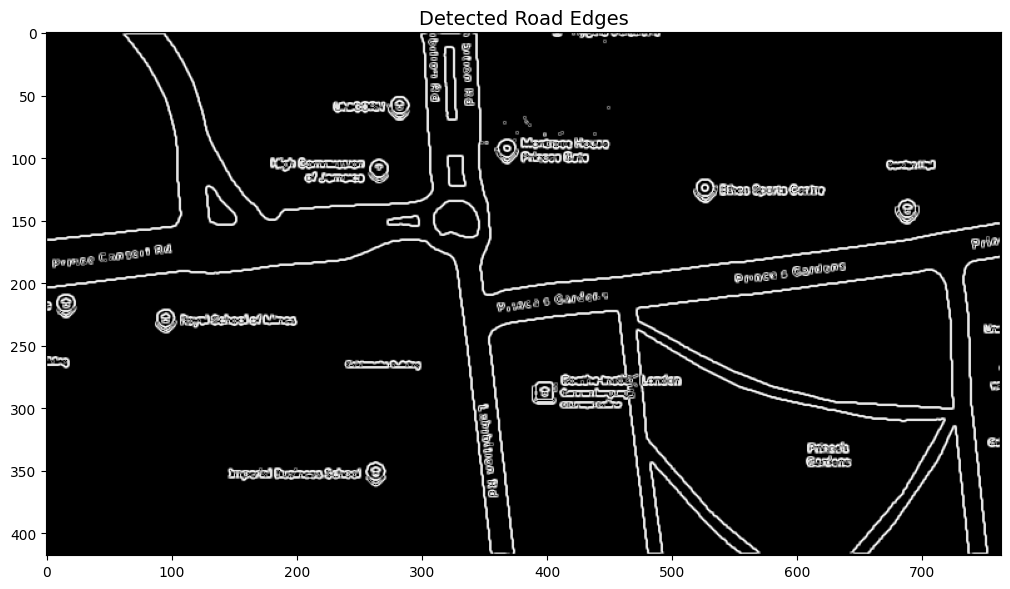

In [264]:
plt.figure(figsize=(14, 6))

# Plot the detected edges
plt.imshow(road_edges, cmap='gray')
plt.title('Detected Road Edges', fontsize=14)
plt.tight_layout()
plt.show()

In [265]:
blue_mask = (B > 0.6) & (B > R*1.5) & (B > G*1.5)

# Extract all Blue Pixel coordinates
# np.argwhere returns [row, col], so we flip to [x, y]
coords = np.argwhere(blue_mask)
path_points = coords[:, ::-1] 

# sort by X in descending order so the robot starts at the red marker side.
path_points = path_points[path_points[:, 0].argsort()[::-1]]


print(f"Number of via points: {len(path_points)}.")

Number of via points: 17.


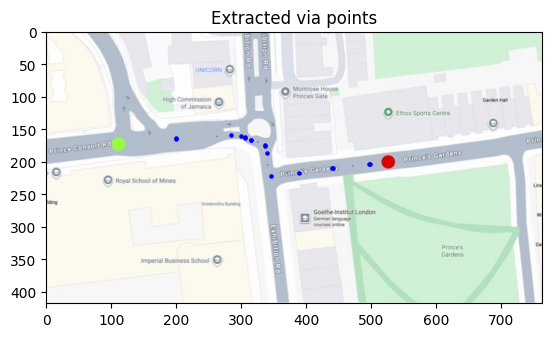

In [266]:
plt.imshow(mpimg.imread('CW2Map.jpg'))
plt.scatter(path_points[:, 0], path_points[:, 1], color='blue', s=5)
plt.title("Extracted via points")
plt.show()

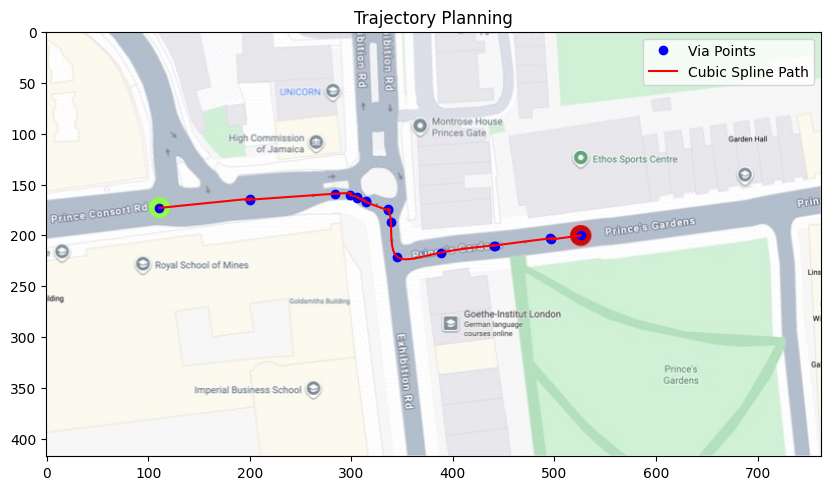

In [267]:
# Add start and end points to the path
path_points = np.vstack((start_pos, path_points, end_pos))
# Parameterize the path
u_nodes = np.linspace(0, 1, len(path_points))
u_fine = np.linspace(0, 1, 300) # 300 points for a smooth line

# bc_type='natural' ensures second derivatives are zero at endpoints
cs_x = CubicSpline(u_nodes, path_points[:, 0], bc_type='natural')
cs_y = CubicSpline(u_nodes, path_points[:, 1], bc_type='natural')

# Generate the smooth path
smooth_x = cs_x(u_fine)
smooth_y = cs_y(u_fine)
smooth_path = np.vstack((smooth_x, smooth_y)).T


img = plt.imread('CW2Map.jpg')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.plot(path_points[:, 0], path_points[:, 1], 'bo', label='Via Points')
plt.plot(smooth_path[:, 0], smooth_path[:, 1], 'r-', label='Cubic Spline Path')
plt.legend()
plt.title("Trajectory Planning")
plt.show()

In [268]:
def calculate_road_width(mask, start_coord, end_coord, axis='x'):
    """
    Calculates the average width of the road in a given range.
    axis='x' scans across columns (good for horizontal roads like Prince's Gardens).
    axis='y' scans across rows (good for vertical roads like Exhibition Road).
    """
    widths = []
    if axis == 'x':
        # For each column in range, count the longest continuous strip of road pixels
        for x in range(start_coord, end_coord):
            col = mask[:, x]
            count = 0
            max_strip = 0
            for pixel in col:
                if pixel: count += 1
                else:
                    max_strip = max(max_strip, count)
                    count = 0
            if max_strip > 5: widths.append(max_strip)
    else:
        # For each row in range, count the longest continuous strip
        for y in range(start_coord, end_coord):
            row = mask[y, :]
            count = 0
            max_strip = 0
            for pixel in row:
                if pixel: count += 1
                else:
                    max_strip = max(max_strip, count)
                    count = 0
            if max_strip > 5: widths.append(max_strip)
            
    return np.mean(widths) if widths else 0

# Measure Prince's Gardens
pg_width_px = calculate_road_width(road_mask, 500, 650, axis='x')

# 2. Measure Exhibition Road
ex_width_px = calculate_road_width(road_mask, 350, 400, axis='y')


print(f"Prince's Gardens Avg Width: {pg_width_px:.2f} px")
print(f"Exhibition Road Avg Width: {ex_width_px:.2f} px")

Prince's Gardens Avg Width: 21.95 px
Exhibition Road Avg Width: 17.46 px


In [269]:
EX_WIDTH = 7
PG_WIDTH = 9.5

scale = (EX_WIDTH / ex_width_px + PG_WIDTH / pg_width_px) / 2
print(f"Estimated Scale: {scale:.4f} meters per pixel")

Estimated Scale: 0.4169 meters per pixel


In [270]:
MIN_WIDTH = 3.85

print(f"Max Car Width: {MIN_WIDTH / 4} m") 

Max Car Width: 0.9625 m


In [271]:
CAR_WIDTH = 0.8
WHEEL_DIAMETER = 0.2

In [272]:
dt = 0.1           # time step (seconds)
V_TARGET = 0.5         # target linear velocity (m/s)


robot_velocities = []

wheel_trajectory = []  # To record wheel speeds

# Convert your smooth_path from pixels to meters
path_meters = smooth_path * scale

# Initialize state [x, y, theta]
x_current, y_current = path_meters[0]
theta_current = np.arctan2(path_meters[1][1] - path_meters[0][1], 
                           path_meters[1][0] - path_meters[0][0])

robot_trajectory = [[x_current, y_current, theta_current]]

# 2. Continuous Trajectory Tracking Loop
target_idx = 1
# Run the simulation until the robot reaches the final point in the path
while target_idx < len(path_meters):
    target_x, target_y = path_meters[target_idx]
    
    # Check how far the robot is from its current target
    dist_to_target = np.sqrt((target_x - x_current)**2 + (target_y - y_current)**2)
    
    # If the robot is within 10cm of the target, move to the next waypoint
    if dist_to_target < 0.1:
        target_idx += 1
        continue # Skip the rest of this loop iteration to fetch the new target
    
    # --- STEP A: CALCULATE DESIRED GLOBAL VELOCITIES ---
    target_theta = np.arctan2(target_y - y_current, target_x - x_current)
    
    # Project constant velocity along the path vector
    x_dot = V_TARGET * np.cos(target_theta)
    y_dot = V_TARGET * np.sin(target_theta)
    
    # Shortest angular difference (normalized to -pi to pi)
    angle_diff = (target_theta - theta_current + np.pi) % (2 * np.pi) - np.pi
    
    # Global angular velocity to correct heading
    theta_dot = angle_diff / dt
    
    # Group into the Global Velocity Vector
    global_vels = np.array([x_dot, y_dot, theta_dot])
    
    
    # --- STEP B: GLOBAL INVERSE KINEMATICS ---
    c = np.cos(theta_current)
    s = np.sin(theta_current)
    
    # Substituting CAR_WIDTH for L, and (WHEEL_DIAMETER / 2) for r.
    # The term L/(2r) simplifies exactly to CAR_WIDTH / WHEEL_DIAMETER.
    inv_kin_matrix = np.array([
        [c / (WHEEL_DIAMETER / 2), s / (WHEEL_DIAMETER / 2),  CAR_WIDTH / WHEEL_DIAMETER],
        [c / (WHEEL_DIAMETER / 2), s / (WHEEL_DIAMETER / 2), -CAR_WIDTH / WHEEL_DIAMETER]
    ])
    
    # Matrix Multiplication
    wheel_speeds = np.dot(inv_kin_matrix, global_vels)
    phi_dot_R = wheel_speeds[0]
    phi_dot_L = wheel_speeds[1]
    
    
    # --- STEP C: FORWARD KINEMATICS (State Update) ---
    # Substituting (WHEEL_DIAMETER / 2) for r, and CAR_WIDTH for L
    v = (WHEEL_DIAMETER / 4) * (phi_dot_R + phi_dot_L)
    omega = (WHEEL_DIAMETER / (2 * CAR_WIDTH)) * (phi_dot_R - phi_dot_L)
    
    x_current += v * np.cos(theta_current) * dt
    y_current += v * np.sin(theta_current) * dt
    theta_current += omega * dt
    
    # Record the physical position
    robot_trajectory.append([x_current, y_current, theta_current])
    # Record wheel speeds for analysis
    wheel_trajectory.append((phi_dot_R, phi_dot_L))
    # record robot velocities for analysis
    robot_velocities.append((v, omega))

# 3. Format Output
robot_trajectory = np.array(robot_trajectory)
robot_trajectory[:, 0] /= scale 
robot_trajectory[:, 1] /= scale

print(f"Simulation complete! Generated {len(robot_trajectory)} tracking steps.")

Simulation complete! Generated 4177 tracking steps.


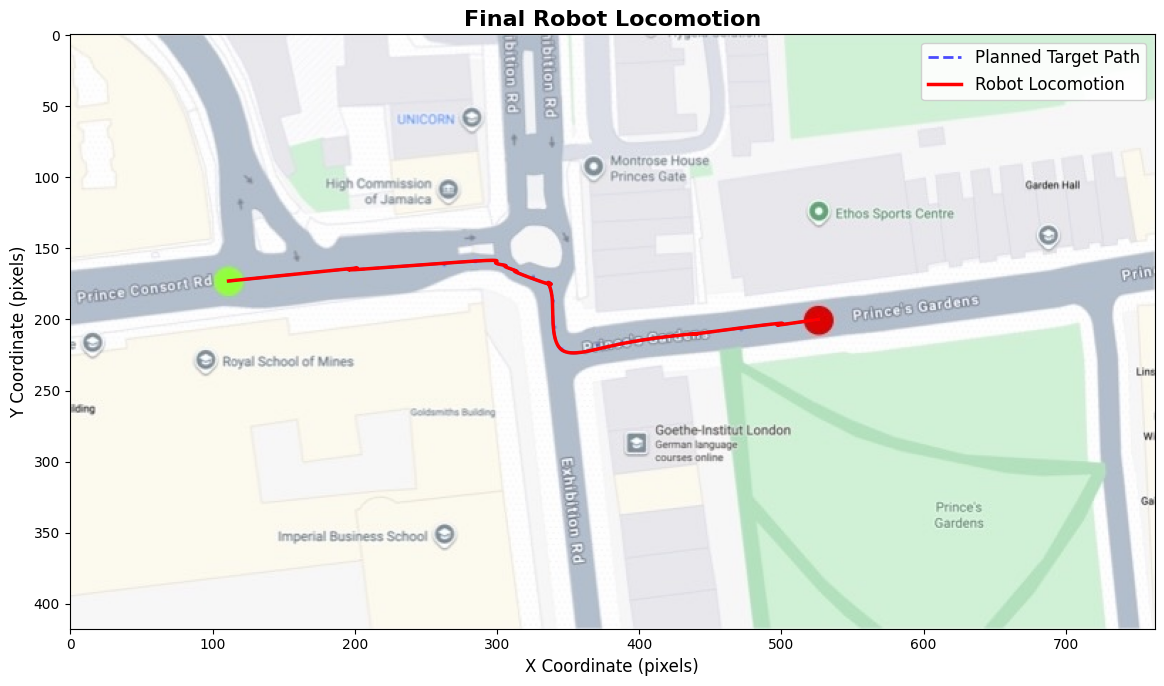

In [273]:
# show the robot trajectory
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.plot(smooth_path[:, 0], smooth_path[:, 1], 'b--', 
         label='Planned Target Path', linewidth=2, alpha=0.7)

plt.plot(robot_trajectory[:, 0], robot_trajectory[:, 1], 'r-', 
         label='Robot Locomotion', linewidth=2.5)


plt.title('Final Robot Locomotion', fontsize=16, fontweight='bold')
plt.xlabel('X Coordinate (pixels)', fontsize=12)
plt.ylabel('Y Coordinate (pixels)', fontsize=12)

plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
plt.show()

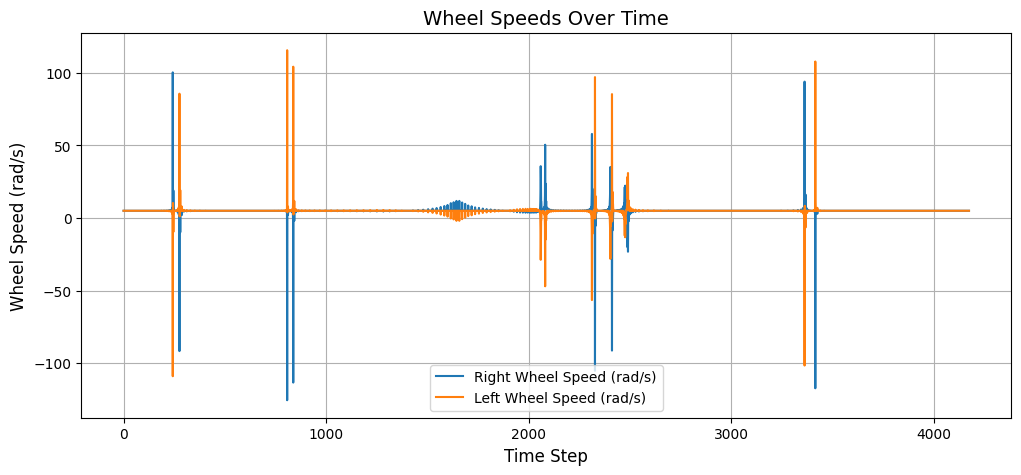

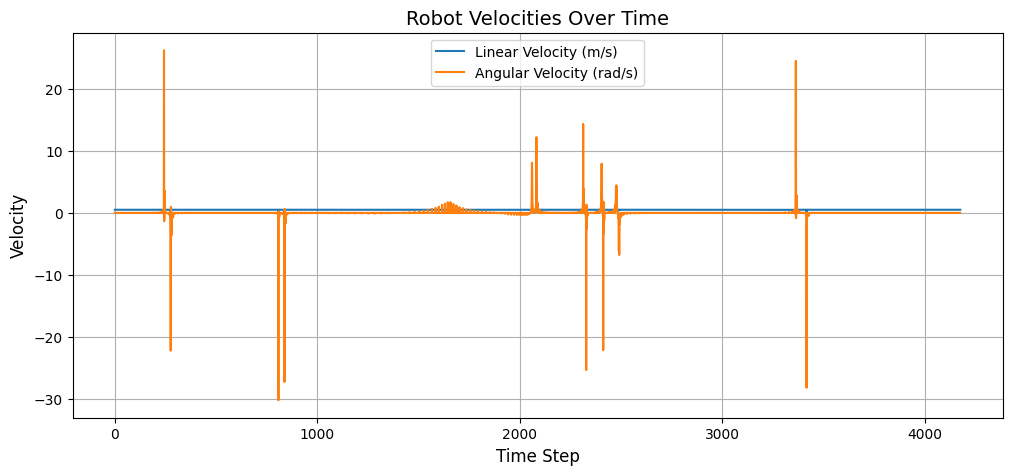

In [274]:
# plot the wheel speeds over time
wheel_trajectory = np.array(wheel_trajectory)
plt.figure(figsize=(12, 5))
plt.plot(wheel_trajectory[:, 0], label='Right Wheel Speed (rad/s)')
plt.plot(wheel_trajectory[:, 1], label='Left Wheel Speed (rad/s)')
plt.title('Wheel Speeds Over Time', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Wheel Speed (rad/s)', fontsize=12)
plt.legend()
plt.grid()
plt.show()  

# plot the robot's linear and angular velocities over time
robot_velocities = np.array(robot_velocities)
plt.figure(figsize=(12, 5))
plt.plot(robot_velocities[:, 0], label='Linear Velocity (m/s)')
plt.plot(robot_velocities[:, 1], label='Angular Velocity (rad/s)')  
plt.title('Robot Velocities Over Time', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Velocity', fontsize=12)
plt.legend()
plt.grid()
plt.show()